In [6]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [15]:
# define state first
class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float
    category: str

In [16]:
# fnc to calculate bmi

def calculate_bmi(state: BMIState) -> BMIState:
    w = state['weight']
    h = state['height']
    bmi = w / (h ** 2)
    state['bmi'] = round(bmi, 2)
    return state

In [17]:
def categorize_bmi(state: BMIState) -> BMIState:
    bmi = state.get('bmi')
    if bmi is None:
        raise ValueError("BMI is missing from state")

    if bmi < 18.5:
        category = 'underweight'
    elif bmi < 25.0:
        category = 'normal'
    elif bmi < 30.0:
        category = 'overweight'
    else:
        category = 'obese'

    state['category'] = category
    return state

In [21]:
# define your graph object
graph = StateGraph(BMIState)


# add nodes to your graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('categorize_bmi', categorize_bmi)

# add edges to your graph

graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'categorize_bmi')
graph.add_edge('categorize_bmi', END)

# compile the graph
workflow = graph.compile()


In [23]:
# execute the graph with input data
output_state = workflow.invoke({'weight': 85, 'height': 1.67})
output_state

{'weight': 85, 'height': 1.67, 'bmi': 30.48, 'category': 'obese'}

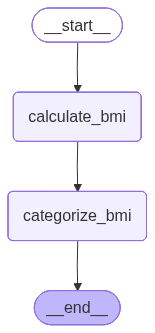

In [24]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())